<a href="https://colab.research.google.com/github/tarannump096-cpu/ML-Project/blob/main/Copy_of_Project_of_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("/content/loan_data.csv")

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,1.0
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,0.0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,1.0
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,1.0
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26257 entries, 0 to 26256
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      26257 non-null  float64
 1   person_gender                   26257 non-null  object 
 2   person_education                26257 non-null  object 
 3   person_income                   26257 non-null  float64
 4   person_emp_exp                  26257 non-null  int64  
 5   person_home_ownership           26257 non-null  object 
 6   loan_amnt                       26257 non-null  float64
 7   loan_intent                     26257 non-null  object 
 8   loan_int_rate                   26257 non-null  float64
 9   loan_percent_income             26256 non-null  float64
 10  cb_person_cred_hist_length      26256 non-null  float64
 11  credit_score                    26256 non-null  float64
 12  previous_loan_defaults_on_file  

In [ ]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,1


In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,26257.000000,2.625700e+04,26257.000000,26257.000000,26257.000000,26256.000000,26256.000000,26256.000000,26256.000000
mean,25.666184,7.392621e+04,3.522794,9294.561450,10.996533,0.141648,4.446793,630.152994,0.222882
std,3.745193,4.542480e+04,3.811009,6110.857069,3.066231,0.086954,2.415021,49.788771,0.416188
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,421.000000,0.000000
25%,23.000000,4.596700e+04,0.000000,5000.000000,8.490000,0.080000,3.000000,600.000000,0.000000
50%,25.000000,6.564700e+04,3.000000,8000.000000,11.010000,0.120000,4.000000,637.000000,0.000000
75%,28.000000,9.069200e+04,6.000000,12000.000000,13.110000,0.190000,6.000000,667.000000,0.000000
max,144.000000,1.440746e+06,125.000000,35000.000000,20.000000,0.660000,10.000000,807.000000,1.000000


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

In [ ]:
categorical_cols

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')

In [ ]:
numerical_cols

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

In [ ]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,1.0
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,0.0
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,1.0
3,23.0,female,Bachelor,79753.0,0.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,1.0
4,24.0,male,Master,66135.0,1.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,1.0


In [ ]:
df.isnull()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26252,False,False,False,False,False,False,False,False,False,False,False,False,False,False
26253,False,False,False,False,False,False,False,False,False,False,False,False,False,False
26254,False,False,False,False,False,False,False,False,False,False,False,False,False,False
26255,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
classes_count = df['loan_amnt'].value_counts()
classes_count

,count
loan_amnt,
10000.0,2160
5000.0,1687
6000.0,1492
12000.0,1468
8000.0,1173
...,...
6525.0,1
15875.0,1
10475.0,1


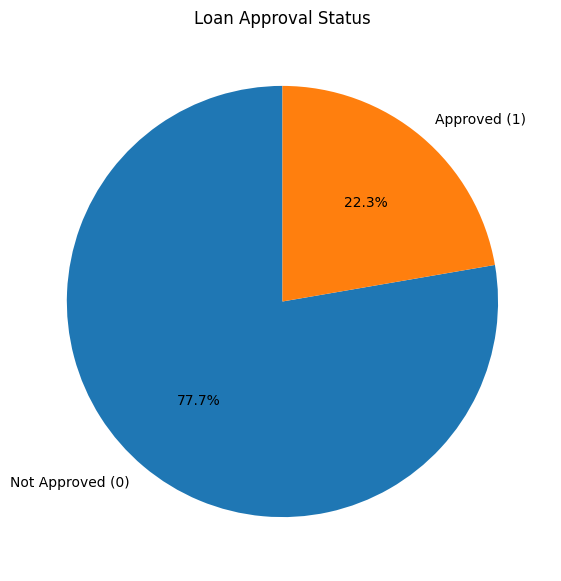

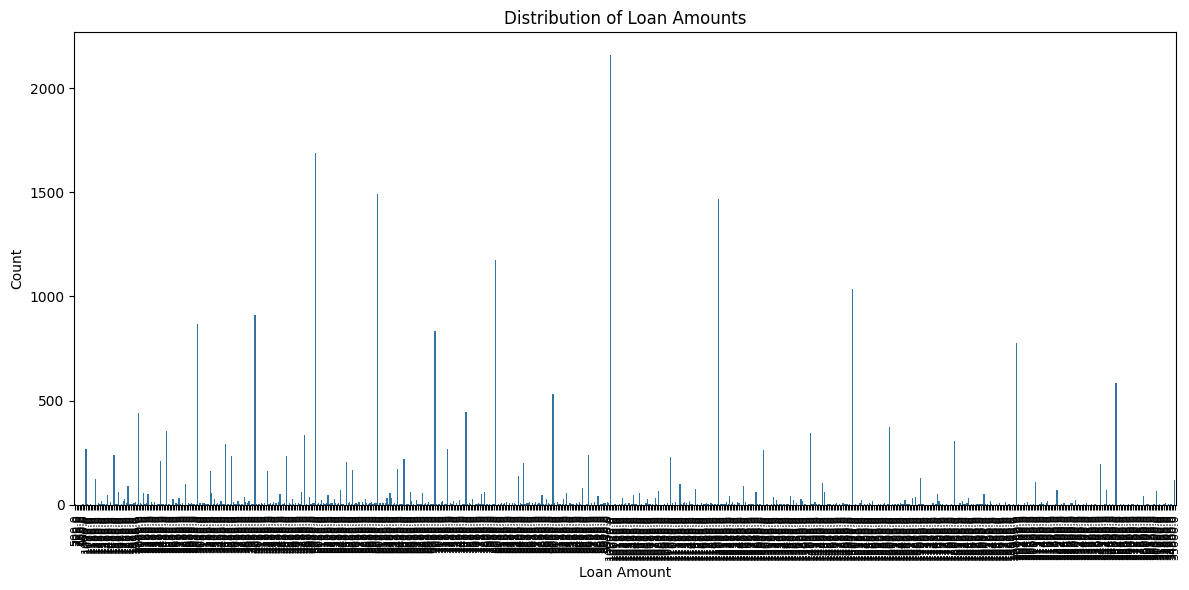

In [ ]:
loan_status_counts = df['loan_status'].round().astype(int).value_counts()
plt.figure(figsize=(7, 7))
plt.pie(loan_status_counts, labels=["Not Approved (0)", "Approved (1)"], autopct='%1.1f%%', startangle=90)
plt.title("Loan Approval Status")
plt.show()

edu_cnt = df['loan_amnt'].value_counts() # This line was already present in the original cell, calculating loan amount counts.

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=edu_cnt.index, y=edu_cnt.values)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

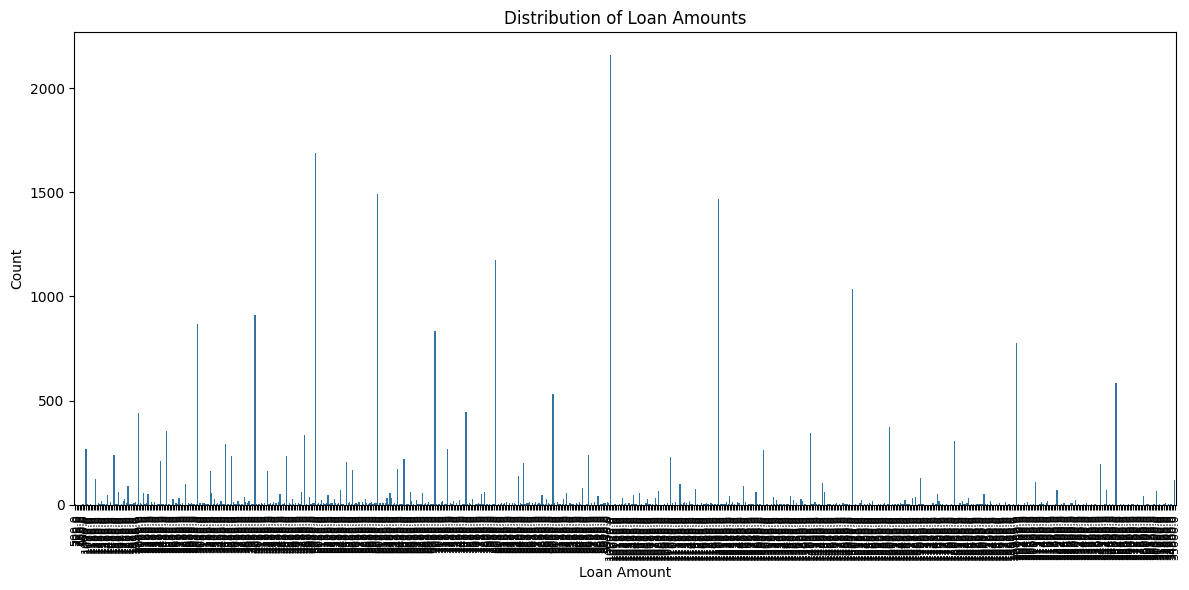

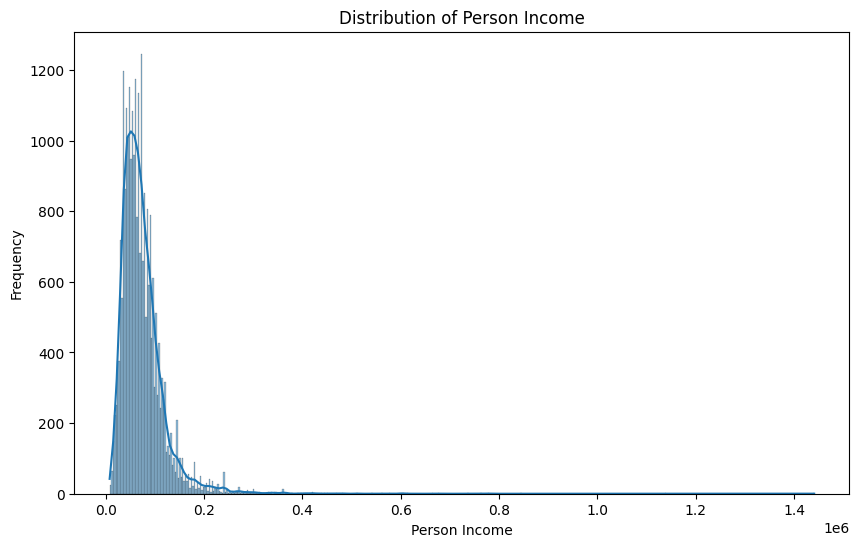

In [ ]:
edu_cnt = df["loan_amnt"].value_counts()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=edu_cnt.index, y=edu_cnt.values)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data = df,
    x = "person_income",
    kde=True
)
plt.title("Distribution of Person Income")
plt.xlabel("Person Income")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='loan_status', ylabel='person_income'>

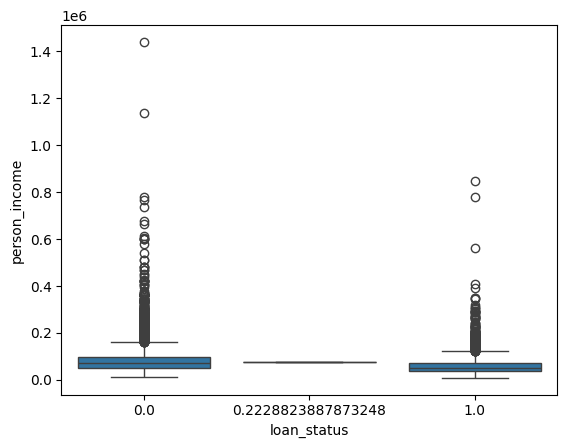

In [ ]:
sns.boxplot(
    data = df,
    x = "loan_status",
    y = "person_income"
)

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

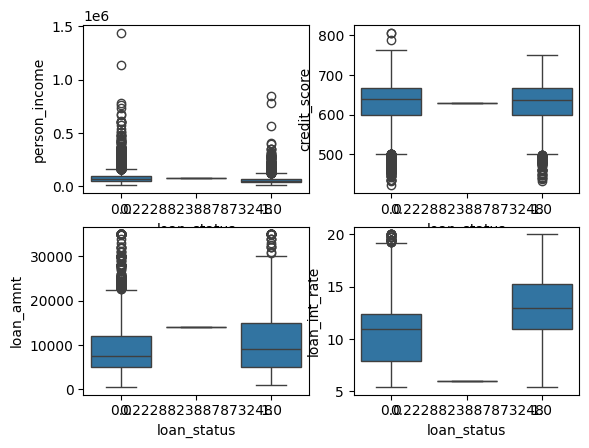

In [ ]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax = axes [0,0],data=df, x='loan_status', y='person_income')
sns.boxplot(ax = axes [0,1],data=df, x='loan_status', y='credit_score')
sns.boxplot(ax = axes [1,0],data=df, x='loan_status', y='loan_amnt')
sns.boxplot(ax = axes [1,1],data=df, x='loan_status', y='loan_int_rate')

<Axes: xlabel='loan_amnt', ylabel='Count'>

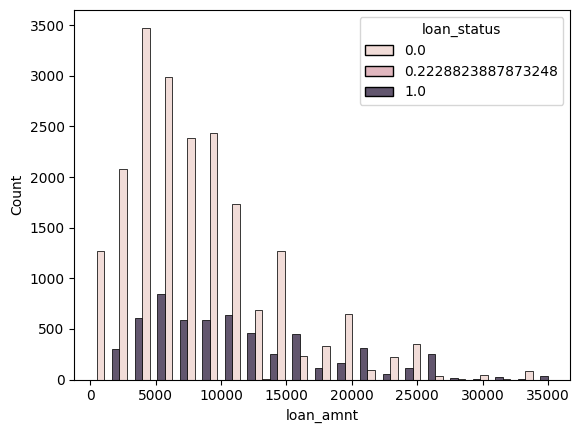

In [ ]:
sns.histplot(
    data = df,
    x = "loan_amnt",
    hue = "loan_status",
    bins = 20,
    multiple = "dodge"
)

<Axes: xlabel='person_income', ylabel='Count'>

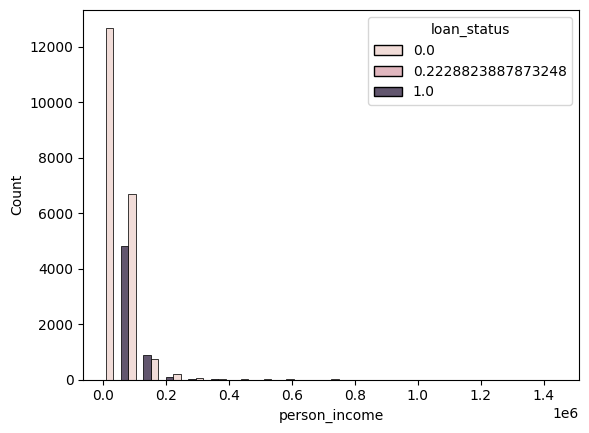

In [ ]:
sns.histplot(
    data = df,
    x = "person_income",
    hue = "loan_status",
    bins = 20,
    multiple = "dodge"
)

In [ ]:
df = df.drop("loan_status", axis=1)

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No
1,21.0,female,High School,12282.0,0.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes
2,25.0,female,High School,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No
3,23.0,female,Bachelor,79753.0,0.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No
4,24.0,male,Master,66135.0,1.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No


In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26257 entries, 0 to 26256
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      26257 non-null  float64
 1   person_gender                   26257 non-null  object 
 2   person_education                26257 non-null  object 
 3   person_income                   26257 non-null  float64
 4   person_emp_exp                  26257 non-null  float64
 5   person_home_ownership           26257 non-null  object 
 6   loan_amnt                       26257 non-null  float64
 7   loan_intent                     26257 non-null  object 
 8   loan_int_rate                   26257 non-null  float64
 9   loan_percent_income             26257 non-null  float64
 10  cb_person_cred_hist_length      26257 non-null  float64
 11  credit_score                    26257 non-null  float64
 12  previous_loan_defaults_on_file  

In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
col = ["person_age", "person_gender", "person_education", "person_emp_exp"]
le = LabelEncoder()
df["person_education"] = le.fit_transform(df["person_education"])
# Corrected: Encoding 'person_gender' as it's a categorical column in the 'col' list.
df["person_gender"] = le.fit_transform(df["person_gender"])

In [ ]:
# col = ["person_age", "person_gender", "person_education", "person_emp_exp"]
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,0,4,71948.0,0.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No
1,21.0,0,3,12282.0,0.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes
2,25.0,0,3,12438.0,3.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No
3,23.0,0,1,79753.0,0.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No
4,24.0,1,4,66135.0,1.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No


In [ ]:
col = ["person_age", "person_gender", "person_education", "person_emp_exp"]
ohe = OneHotEncoder(drop = "first", sparse_output=False, handle_unknown = "ignore")
encoded = ohe.fit_transform(df[col])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(col), index=df.index)
df = pd.concat([df.drop(columns=col), encoded_df], axis=1)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26257 entries, 0 to 26256
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_income                   26257 non-null  float64
 1   person_home_ownership           26257 non-null  object 
 2   loan_amnt                       26257 non-null  float64
 3   loan_intent                     26257 non-null  object 
 4   loan_int_rate                   26257 non-null  float64
 5   loan_percent_income             26257 non-null  float64
 6   cb_person_cred_hist_length      26257 non-null  float64
 7   credit_score                    26257 non-null  float64
 8   previous_loan_defaults_on_file  26257 non-null  object 
 9   person_age_21.0                 26257 non-null  float64
 10  person_age_22.0                 26257 non-null  float64
 11  person_age_23.0                 26257 non-null  float64
 12  person_age_24.0                 

,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_age_21.0,...,person_emp_exp_12.0,person_emp_exp_13.0,person_emp_exp_14.0,person_emp_exp_15.0,person_emp_exp_16.0,person_emp_exp_17.0,person_emp_exp_100.0,person_emp_exp_101.0,person_emp_exp_121.0,person_emp_exp_125.0
0,71948.0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12282.0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12438.0,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,79753.0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,66135.0,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
